In [2]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict

In [3]:
# define state 
class BMIState(TypedDict):
    weight:float
    height:float
    bmi:float


In [23]:
def bmi_calc(state:BMIState)->BMIState:
    bmi= state["weight"]/state["height"]**2
    state["bmi"] = bmi 
    return {"bmi":bmi}


In [24]:
# define graph
graph = StateGraph(BMIState)

In [25]:
# add node to graph 
graph.add_node("bmi_calculator",bmi_calc)

In [26]:
# add edges
graph.add_edge(START,"bmi_calculator")
graph.add_edge("bmi_calculator",END)


In [27]:
# compiler graph
workflow = graph.compile()

In [28]:
initialState={
    "weight":58,
    "height":1.4
}
final_output = workflow.invoke(initialState)
print(final_output)

{'weight': 58, 'height': 1.4, 'bmi': 29.59183673469388}


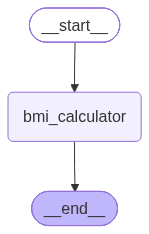

In [14]:
from IPython.display import Image

Image(workflow.get_graph().draw_mermaid_png())